# ATM Straddle Backtest

This notebook runs the backtest for the `ATMStraddleStrategy` and reports the results.

**Strategy**: At every second, find the strike nearest to the front-month futures price. Hold a long straddle (CE + PE) at that strike. Roll when the ATM strike changes. Force-close at 15:29:59.

**Universe**: NIFTY + BANKNIFTY, November 2022 (21 trading days).

Plots are saved to `results/`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../src")))

import mft.metrics as metrics
from mft.universe import Universe
from mft.engine import BacktestEngine
from mft.strategy.atm_straddle import ATMStraddleStrategy

DATA_DIR    = Path("../data/allData")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

## 1. Run the backtest

The `strategy_factory` argument is the only thing that changes between strategies — swap it out to test a different one.

In [2]:
universe = Universe(DATA_DIR)
engine   = BacktestEngine(universe, DATA_DIR, strategy_factory=ATMStraddleStrategy)
result   = engine.run_all(underliers=["NIFTY", "BANKNIFTY"])


=== NIFTY ===
Running backtest for NIFTY on 2022-11-01 ... done. Final PnL: -2.05, trades: 688
Running backtest for NIFTY on 2022-11-02 ... done. Final PnL: 27.55, trades: 1024
Running backtest for NIFTY on 2022-11-03 ... done. Final PnL: -81.10, trades: 1092
Running backtest for NIFTY on 2022-11-04 ... done. Final PnL: -56.35, trades: 788
Running backtest for NIFTY on 2022-11-07 ... done. Final PnL: -36.50, trades: 512
Running backtest for NIFTY on 2022-11-09 ... done. Final PnL: 56.90, trades: 1168
Running backtest for NIFTY on 2022-11-10 ... done. Final PnL: -13.75, trades: 292
Running backtest for NIFTY on 2022-11-11 ... done. Final PnL: -20.40, trades: 1196
Running backtest for NIFTY on 2022-11-14 ... done. Final PnL: -0.45, trades: 380
Running backtest for NIFTY on 2022-11-15 ... done. Final PnL: -47.40, trades: 316
Running backtest for NIFTY on 2022-11-16 ... done. Final PnL: 15.50, trades: 796
Running backtest for NIFTY on 2022-11-17 ... done. Final PnL: 5.70, trades: 744
Runn

## 2. Summary table

One row per underlier, all key metrics.

In [3]:
metrics.summary_table(result)

,total_pnl,mean_daily_pnl,std_daily_pnl,best_day,worst_day,sharpe,sortino,calmar,max_drawdown,max_dd_duration,win_rate,profit_factor,avg_holding_secs,total_trades
underlier,,,,,,,,,,,,,,
BANKNIFTY,-1507.45,-71.78,65.66,45.85,-257.2,-17.356,-18.962,-12.098,1495.30,19,9.5%,0.03,111.5,16944
NIFTY,-507.85,-24.18,35.70,56.90,-104.5,-10.754,-14.409,-11.426,533.35,19,19.0%,0.17,120.0,15748


### Reading the summary table

**Total PnL**: BANKNIFTY lost 1507 index points, NIFTY lost 508. All in index points, multiplier = 1 (see assumptions).

**Sharpe / Sortino / Calmar**: All deeply negative for both underliers. These are not meaningful as standalone signals with only 21 days — stated here for completeness with the caveat that N=21 makes all risk-adjusted metrics statistically unreliable estimates.

**Max drawdown duration = 19/21**: Both underliers were in drawdown for 19 of 21 trading days. The strategy briefly reached its peak on Nov 2 and never recovered from that point forward.

**Win rate**: BANKNIFTY 9.5%, NIFTY 19%. Out of 21 days, BANKNIFTY was profitable on 2 days and NIFTY on 4. This is characteristic of a long straddle in a low-volatility regime — theta bleeds you most days and you only win on high-movement days.

**Profit factor**: 0.03 and 0.17. For every ₹1 made on winning days, BANKNIFTY lost ₹33 and NIFTY lost ₹6 on losing days.

**Avg holding time**: ~111-120 seconds. The average position was held for under 2 minutes before being rolled. On days with heavy ping-pong (adjacent strikes), many individual straddle holds lasted just 1-2 seconds.

**Total trades**: 32,692 across the month. At the lot size of 1 (which is not a realistic lot — NIFTY lot = 50, BANKNIFTY lot = 25 in November 2022), this is the raw transaction count. See cost sensitivity section.

## 3. Daily PnL table

In [4]:
result.daily_pnl

underlier,BANKNIFTY,NIFTY
date,,
2022-11-01,-58.00,-2.05
2022-11-02,45.85,27.55
2022-11-03,-257.20,-81.10
2022-11-04,-37.60,-56.35
2022-11-07,-100.35,-36.50
2022-11-09,-58.35,56.90
2022-11-10,-191.60,-13.75
2022-11-11,-92.30,-20.40
2022-11-14,-12.90,-0.45


## 4. Cumulative PnL

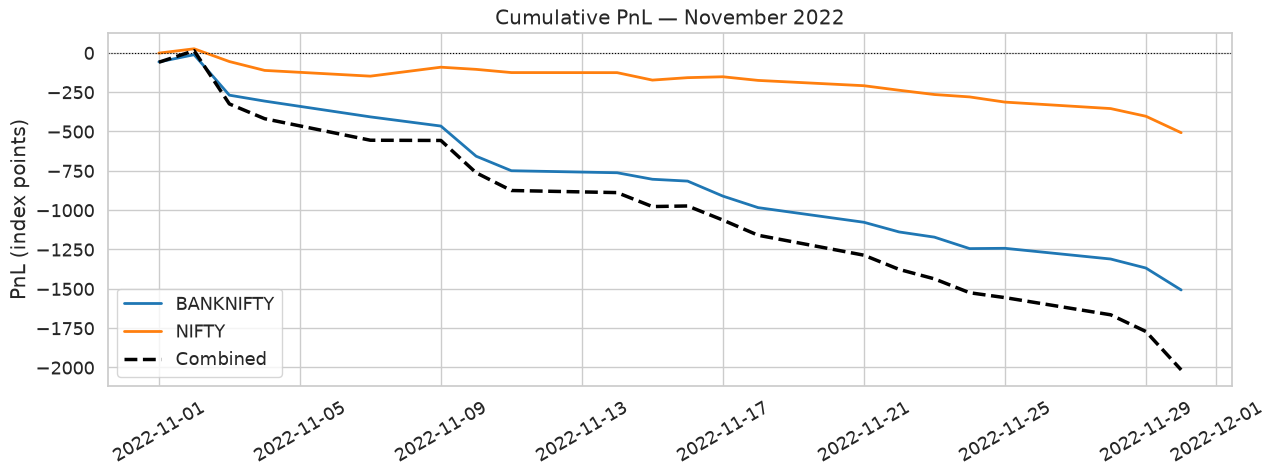

In [5]:
fig = metrics.plot_cumulative_pnl(result)
fig.savefig(RESULTS_DIR / "01_cumulative_pnl.png", dpi=150, bbox_inches="tight")

**What:** Cumulative sum of daily PnL from Nov 1 to Nov 30.

**Observation:** BANKNIFTY (blue) deteriorates faster and more deeply than NIFTY (orange). Both only had positive cumulative PnL on Nov 2, before entering a continuous losing streak. The combined portfolio (black dashed) finished at -2015 index points.

## 5. Daily PnL bars

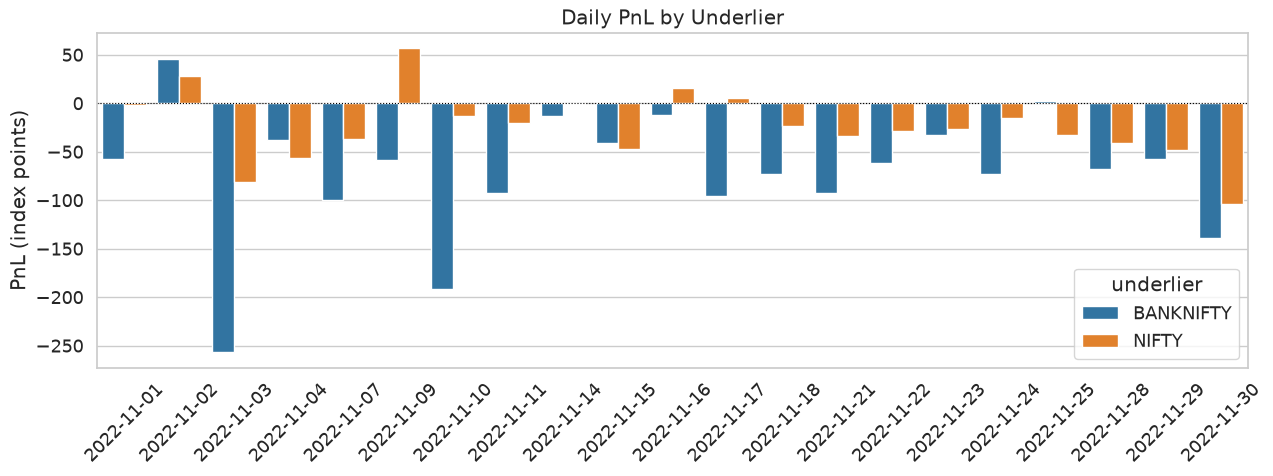

In [6]:
fig = metrics.plot_daily_pnl(result)
fig.savefig(RESULTS_DIR / "02_daily_pnl.png", dpi=150, bbox_inches="tight")

**What:** Daily profit and loss for each underlier, shown side by side.

**Observation:** Nov 3 (expiry day for BANKNIFTY front week) was by far the worst day — BANKNIFTY lost 257 points in a single session. This is not coincidental: on expiry day, options premium collapses rapidly toward intrinsic value. The straddle you're long loses value quickly as expiry approaches and the market settles. The two best days (Nov 2 and Nov 9) were days where the underlying made a large sustained directional move.

## 6. Drawdown

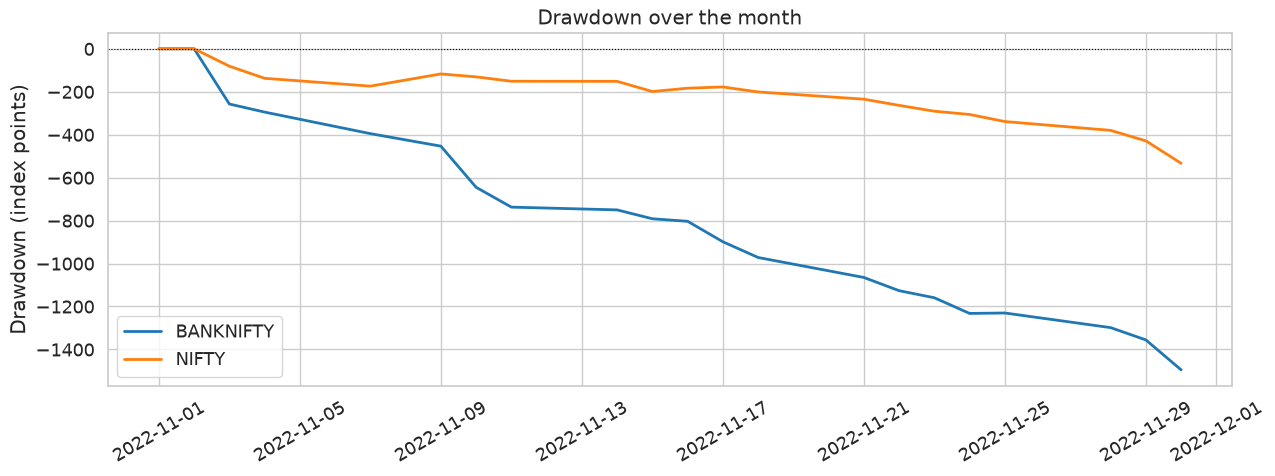

In [7]:
fig = metrics.plot_drawdown(result)
fig.savefig(RESULTS_DIR / "03_drawdown.png", dpi=150, bbox_inches="tight")

**What:** How far below the running equity peak you are at each point. Starts at 0 and goes negative whenever cumulative PnL falls below its previous high.

**Observation:** Neither line returns to 0 after Nov 2. Max drawdown duration = 19 days for both — the strategy was effectively in continuous drawdown for the entire month after the first week. BANKNIFTY's max drawdown was 1495 points, NIFTY's was 533.

## 7. Intraday MTM — sample days

Per-second MTM for one BANKNIFTY day and one NIFTY day.

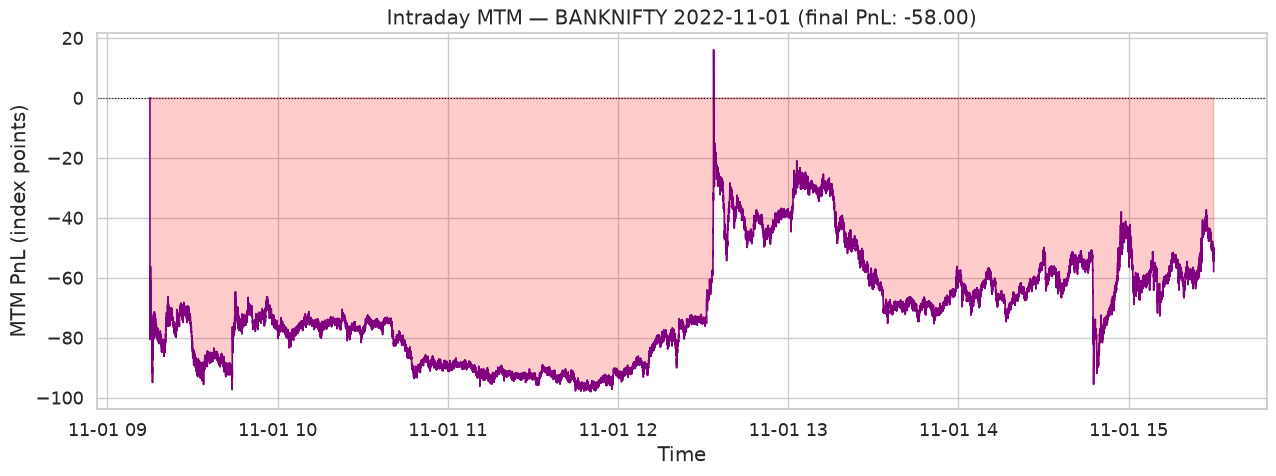

In [8]:
fig = metrics.plot_intraday_mtm(result, trading_date="2022-11-01", underlier="BANKNIFTY")
fig.savefig(RESULTS_DIR / "04_intraday_mtm_banknifty.png", dpi=150, bbox_inches="tight")

**What:** Mark-to-market equity at every second of the Nov 1 session for BANKNIFTY.

**Observation:** The strategy was negative almost all day (-70 to -100 range), with one brief recovery spike near 12:30 PM where it nearly reached breakeven. The spike corresponds to a large fast move in BANKNIFTY that momentarily made the long straddle profitable. But the market quickly calmed, and the strategy ended at -58.

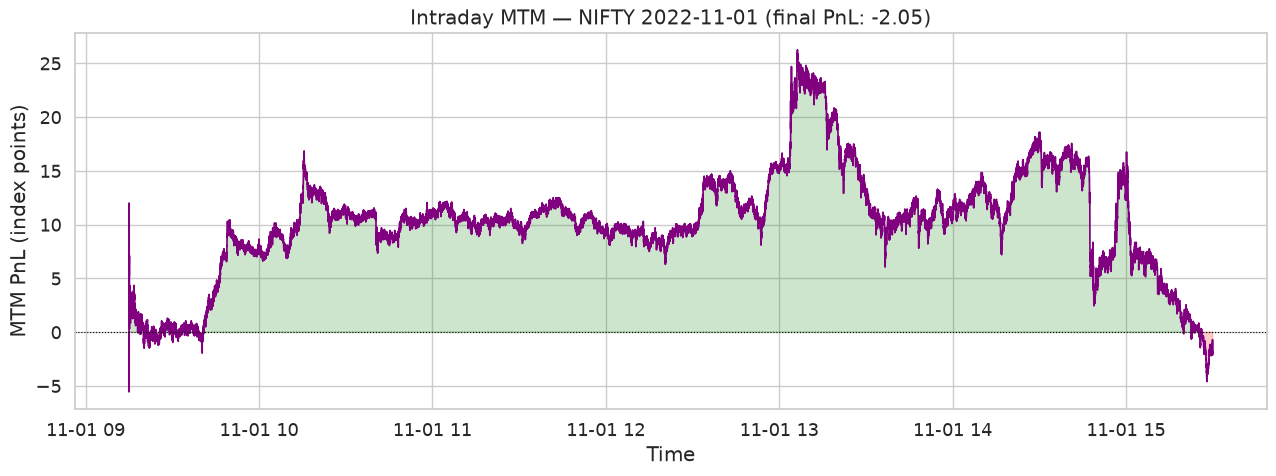

In [9]:
fig = metrics.plot_intraday_mtm(result, trading_date="2022-11-01", underlier="NIFTY")
fig.savefig(RESULTS_DIR / "05_intraday_mtm_nifty.png", dpi=150, bbox_inches="tight")

**What:** Mark-to-market equity at every second of the Nov 1 session for NIFTY.

**Observation:** Unlike BANKNIFTY, NIFTY spent most of the day IN PROFIT (green shading). It peaked near +26 in early afternoon, holding positive for roughly 5 hours. The final 30 minutes wiped out all gains, and the day closed at -2.05.

## 8. Rolls per day

How many times the strategy rolled the ATM strike each day. A roll = the futures price crossed into a new nearest-strike bucket while the position was open.

          rolls                                                           \
          count        mean        std   min    25%    50%    75%    max   
underlier                                                                  
BANKNIFTY  21.0  200.714286  79.473356  73.0  119.0  214.0  262.0  341.0   
NIFTY      21.0  186.476190  80.020384  72.0  127.0  185.0  245.0  339.0   

          trades                                                               
           count        mean         std    min    25%    50%     75%     max  
underlier                                                                      
BANKNIFTY   21.0  806.857143  317.893423  296.0  480.0  860.0  1052.0  1368.0  
NIFTY       21.0  749.904762  320.081537  292.0  512.0  744.0   984.0  1360.0  


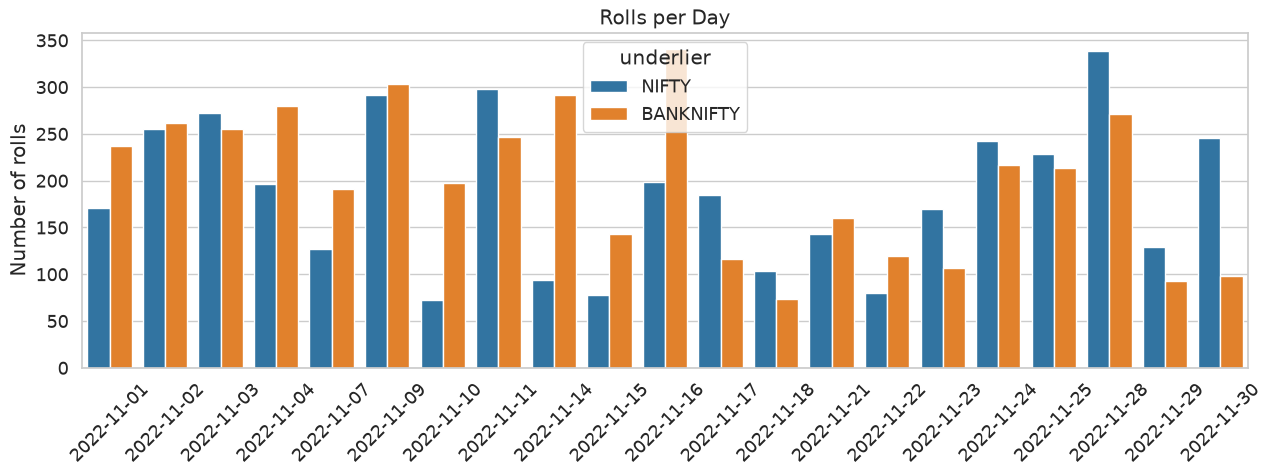

In [10]:
print(metrics.rolls_per_day(result).groupby("underlier")[["rolls", "trades"]].describe())

fig = metrics.plot_rolls_per_day(result)
fig.savefig(RESULTS_DIR / "06_rolls_per_day.png", dpi=150, bbox_inches="tight")

## 9. Strike held — sample day

Shows the ATM strike held at every second of a single trading day — makes the rolling behaviour visually obvious.

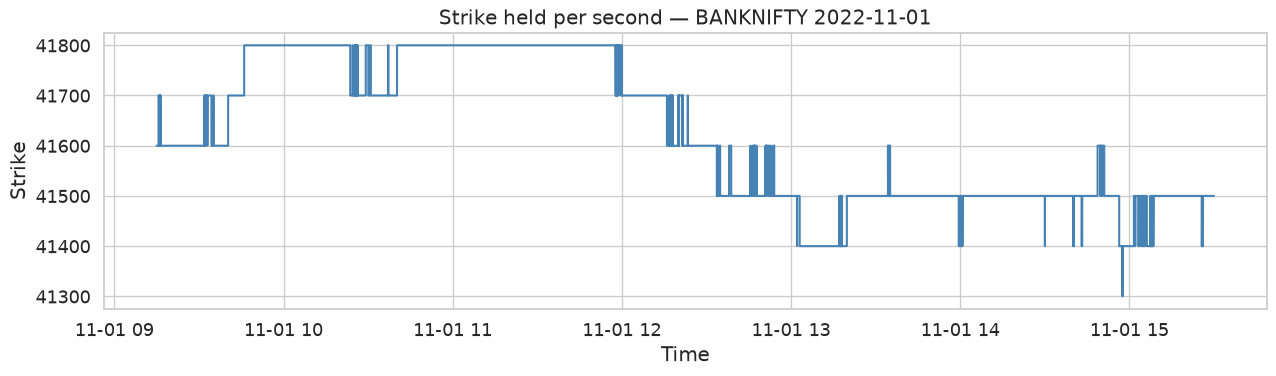

In [11]:
fig = metrics.plot_holdings(result, trading_date="2022-11-01", underlier="BANKNIFTY")
fig.savefig(RESULTS_DIR / "07_strike_held_banknifty.png", dpi=150, bbox_inches="tight")

**What:** Which strike the strategy was holding at every second on Nov 1 for BANKNIFTY.

**Observation:** The strike trended downward from ~41600 in the morning to ~41500 in the afternoon, reflecting BANKNIFTY's intraday decline. The rapid vertical oscillations ("ping-pong") appear wherever the futures price hovered near the midpoint between two adjacent strikes — the strategy rolled back and forth many times within a few minutes.

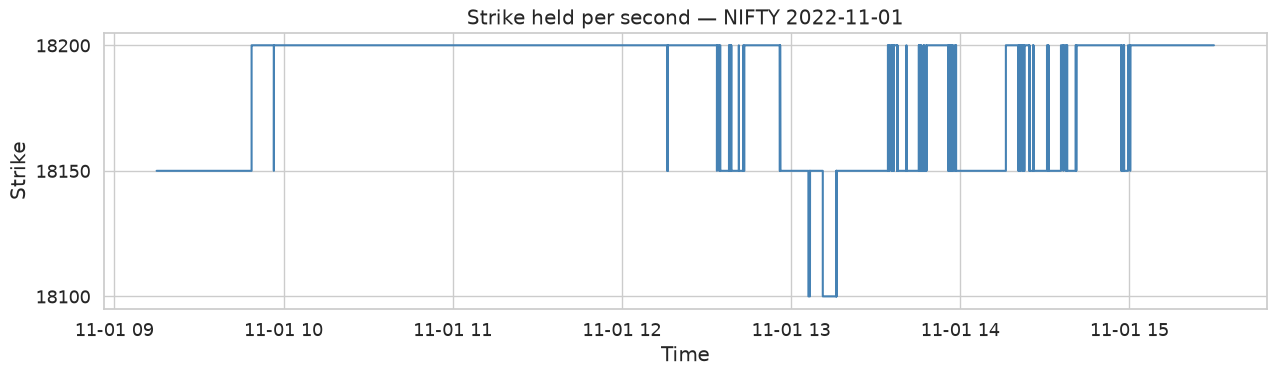

In [12]:
fig = metrics.plot_holdings(result, trading_date="2022-11-01", underlier="NIFTY")
fig.savefig(RESULTS_DIR / "08_strike_held_nifty.png", dpi=150, bbox_inches="tight")

**What:** Which strike the strategy held at every second on Nov 1 for NIFTY.

**Observation:** Less directional drift than BANKNIFTY. The large dip to 18100 near 13:00 corresponds to a sharp intraday drop in NIFTY before it recovered. The denser oscillations in the afternoon show the ping-pong behaviour.

## 10. Transaction cost sensitivity

The strategy rolls frequently (~hundreds of times per day). Even small per-trade costs have a large cumulative impact. This table shows gross PnL vs net PnL at different cost assumptions.

In [13]:
metrics.cost_sensitivity(result)

,cost_bps,total_notional,cost_drag,gross_pnl,net_pnl
0,0,4930449.6,0.00,-2015.3,-2015.30
1,1,4930449.6,493.04,-2015.3,-2508.34
2,2,4930449.6,986.09,-2015.3,-3001.39
3,5,4930449.6,2465.22,-2015.3,-4480.52
4,10,4930449.6,4930.45,-2015.3,-6945.75


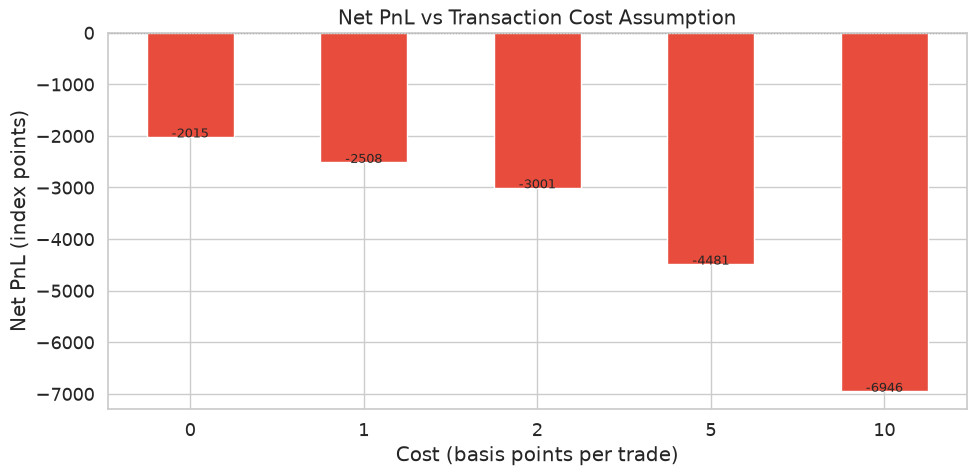

In [14]:
fig = metrics.plot_cost_sensitivity(result)
fig.savefig(RESULTS_DIR / "09_cost_sensitivity.png", dpi=150, bbox_inches="tight")

**What:** Net PnL at different per-transaction cost assumptions, in basis points of the option premium.

**Observation:** Gross PnL (0 bps) = -2015. At just 1 bps: -2508. At 5 bps: -4481. At 10 bps: -6946. The total notional traded was approximately 49.3 million index points across 32,692 transactions.

## 11. Trade log sample

The raw trade log — every executed BUY and SELL, with timestamps and prices.

In [15]:
trades = result.trades_df
print(f"Total trades: {len(trades):,}")
trades.head(20)

Total trades: 32,692


,timestamp,date,underlier,instrument,expiry,strike,option_type,side,price,qty
0,2022-11-01 09:15:00,2022-11-01,NIFTY,NIFTY22110318150CE.csv,2022-11-03,18150,CE,BUY,69.65,1
1,2022-11-01 09:15:00,2022-11-01,BANKNIFTY,BANKNIFTY22110341600PE.csv,2022-11-03,41600,PE,BUY,414.15,1
2,2022-11-01 09:15:00,2022-11-01,BANKNIFTY,BANKNIFTY22110341600CE.csv,2022-11-03,41600,CE,BUY,270.00,1
3,2022-11-01 09:15:00,2022-11-01,NIFTY,NIFTY22110318150PE.csv,2022-11-03,18150,PE,BUY,107.10,1
4,2022-11-01 09:15:40,2022-11-01,BANKNIFTY,BANKNIFTY22110341600CE.csv,2022-11-03,41600,CE,SELL,264.80,1
5,2022-11-01 09:15:40,2022-11-01,BANKNIFTY,BANKNIFTY22110341600PE.csv,2022-11-03,41600,PE,SELL,338.65,1
6,2022-11-01 09:15:40,2022-11-01,BANKNIFTY,BANKNIFTY22110341700CE.csv,2022-11-03,41700,CE,BUY,219.95,1
7,2022-11-01 09:15:40,2022-11-01,BANKNIFTY,BANKNIFTY22110341700PE.csv,2022-11-03,41700,PE,BUY,395.65,1
8,2022-11-01 09:15:58,2022-11-01,BANKNIFTY,BANKNIFTY22110341700CE.csv,2022-11-03,41700,CE,SELL,216.15,1
9,2022-11-01 09:15:58,2022-11-01,BANKNIFTY,BANKNIFTY22110341700PE.csv,2022-11-03,41700,PE,SELL,403.35,1


## 12. Holdings at any time

what was held at every second — sample from one day

In [16]:
hl = result.day_results[0].holdings_log   # NIFTY Nov 1
print(f"Holdings log shape: {hl.shape}")
hl.head(20)

Holdings log shape: (22499, 7)


,strike,ce_instrument,pe_instrument,ce_entry,pe_entry,ce_mtm_price,pe_mtm_price
timestamp,,,,,,,
2022-11-01 09:15:00,18150,NIFTY22110318150CE.csv,NIFTY22110318150PE.csv,69.65,107.1,69.65,107.10
2022-11-01 09:15:01,18150,NIFTY22110318150CE.csv,NIFTY22110318150PE.csv,69.65,107.1,70.80,100.40
2022-11-01 09:15:02,18150,NIFTY22110318150CE.csv,NIFTY22110318150PE.csv,69.65,107.1,70.80,100.40
2022-11-01 09:15:03,18150,NIFTY22110318150CE.csv,NIFTY22110318150PE.csv,69.65,107.1,71.90,112.45
2022-11-01 09:15:04,18150,NIFTY22110318150CE.csv,NIFTY22110318150PE.csv,69.65,107.1,71.90,113.85
2022-11-01 09:15:05,18150,NIFTY22110318150CE.csv,NIFTY22110318150PE.csv,69.65,107.1,73.15,115.60
2022-11-01 09:15:06,18150,NIFTY22110318150CE.csv,NIFTY22110318150PE.csv,69.65,107.1,69.55,115.20
2022-11-01 09:15:07,18150,NIFTY22110318150CE.csv,NIFTY22110318150PE.csv,69.65,107.1,69.55,112.45
2022-11-01 09:15:08,18150,NIFTY22110318150CE.csv,NIFTY22110318150PE.csv,69.65,107.1,66.05,117.20


In [17]:
from datetime import date

roll_ts = result.trades_df[result.trades_df["date"] == date(2022, 11, 1)]
roll_ts = roll_ts[roll_ts["underlier"] == "BANKNIFTY"]
ts_counts = roll_ts.groupby("timestamp").size()
print("Roll size distribution:")
print(ts_counts.value_counts().head())

Roll size distribution:
4    237
2      2
Name: count, dtype: int64


## 13. Rolling Sharpe ratio

5-day rolling Sharpe per underlier — shows whether performance is stable or deteriorating over the month, rather than collapsing everything into one noisy 21-day estimate.

In [18]:
metrics.rolling_sharpe(result, window=5)

underlier,BANKNIFTY,NIFTY
date,,
2022-11-01,NaN,NaN
2022-11-02,NaN,NaN
2022-11-03,NaN,NaN
2022-11-04,NaN,NaN
2022-11-07,-11.575056,-10.927963
2022-11-09,-11.586897,-4.894957
2022-11-10,-22.047057,-7.886923
2022-11-11,-25.770193,-5.185793
2022-11-14,-21.942472,-1.258288


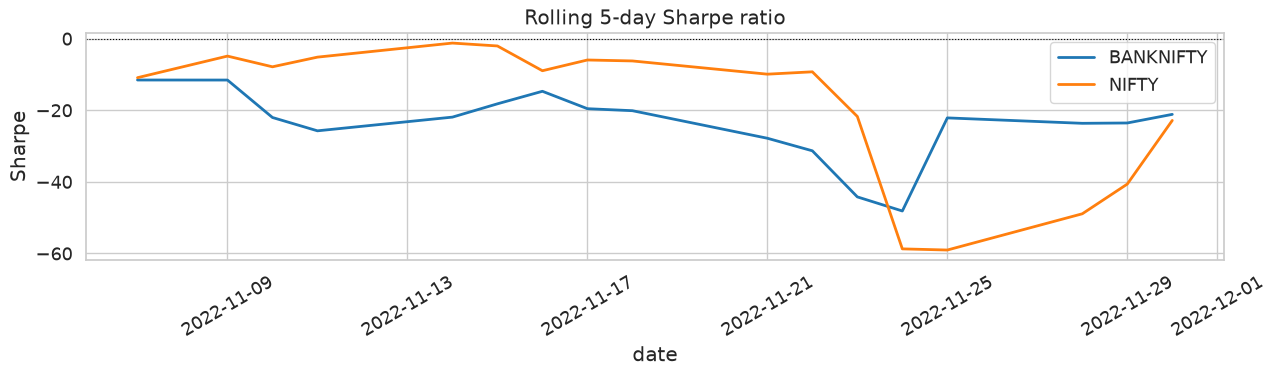

In [19]:
fig = metrics.plot_rolling_sharpe(result, window=5)
fig.savefig(RESULTS_DIR / "10_rolling_sharpe.png", dpi=150, bbox_inches="tight")

### Rolling 5-day Sharpe ratio

**What:** Sharpe ratio computed over a rolling 5-trading-day window.
Each point answers: "how did the strategy perform over the last 5 days?"
The first 4 dates are NaN — a window of 5 is needed before the first estimate.

**Observations:**

- The rolling Sharpe is **negative for the entire month** for both underliers.
  There was no sustained 5-day period where the strategy made money
  consistently enough to produce a positive risk-adjusted return.

- **BANKNIFTY** (blue) deteriorates gradually and steadily through November,
  reaching its worst point around Nov 23–24 (rolling Sharpe ≈ −48).
  This reflects the compounding of consistent daily losses with little variation.

- **NIFTY** (orange) stays relatively stable at −5 to −10 through mid-November —
  meaning it was losing money but consistently, with low day-to-day variance.
  Then it **crashes sharply to −59 around Nov 24–25** before recovering.
  This spike corresponds to NIFTY's worst 5-day stretch of the month:
  Nov 21 (−33.70), Nov 22 (−28.85), Nov 23 (−27.15), Nov 24 (−15.25), Nov 25 (−32.90) —
  five consecutive losing days with high variance, which collapses the Sharpe.

- Both lines **partially recover toward month end** (back toward −20).
  This is not because the strategy started making money — it continued losing —
  but because the window rolled past the worst days and the remaining days
  had smaller, more consistent losses (lower variance improves Sharpe
  even when mean is still negative).